# A1 — Course-stat coverage audit

Read-only diagnostic of the existing latest M1 model and final model splits. This notebook does not retrain or alter pipeline/model artifacts. Its only intentional write is `a1_coverage_audit.json`, kept alongside the selected run and separate from `metrics.json`.

`covered` is defined solely by membership in the train-derived Level-2 `cid_stats` course table used by the course-difficulty enrichment: `df["course_id"].isin(train_covered_course_ids)`. It is not derived from a calendar cutoff, fallback level, or an existing feature value.

In [1]:
import json
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

from src.model_training import MODEL_FEATURES, prepare_X_y
from src.paths import MODEL_DATA_DIR, MODELS_DIR

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)

print('=' * 90)
print('A1 — COURSE-STAT COVERAGE AUDIT')
print('=' * 90)
print('MODE: existing artifacts only; no training and no source-data writes.')

A1 — COURSE-STAT COVERAGE AUDIT
MODE: existing artifacts only; no training and no source-data writes.


In [2]:
# Select the latest persistent run that contains the M1 booster and its feature contract.
run_candidates = [
    path for path in (MODELS_DIR / 'runs').iterdir()
    if path.is_dir()
    and (path / 'm1_pass_model.lgbm').is_file()
    and (path / 'feature_contract.json').is_file()
]
if not run_candidates:
    raise FileNotFoundError(f'No persistent M1 run with a feature contract under {MODELS_DIR / "runs"}')

LATEST_RUN_DIR = max(run_candidates, key=lambda path: (path / 'm1_pass_model.lgbm').stat().st_mtime)
M1_MODEL_PATH = LATEST_RUN_DIR / 'm1_pass_model.lgbm'
CONTRACT_PATH = LATEST_RUN_DIR / 'feature_contract.json'
A1_OUTPUT_PATH = LATEST_RUN_DIR / 'a1_coverage_audit.json'

with CONTRACT_PATH.open(encoding='utf-8') as handle:
    feature_contract = json.load(handle)

if feature_contract['features'] != MODEL_FEATURES:
    raise AssertionError(
        'The current MODEL_FEATURES list differs from the selected M1 feature contract. '
        'Stop rather than scoring with a mismatched matrix.'
    )

categorical_levels = {
    name: [int(value) for value in values]
    for name, values in feature_contract['categorical_levels'].items()
}
m1_booster = lgb.Booster(model_file=str(M1_MODEL_PATH))

print(f'Latest persistent run : {LATEST_RUN_DIR.name}')
print(f'M1 booster            : {M1_MODEL_PATH.name}')
print(f'Feature contract       : {CONTRACT_PATH.name} ({feature_contract["n_features"]} features)')
print(f'A1 output (only write) : {A1_OUTPUT_PATH}')

Latest persistent run : 2026-07-12_1513__remove-dead-const
M1 booster            : m1_pass_model.lgbm
Feature contract       : feature_contract.json (39 features)
A1 output (only write) : D:\AI\Real projects\Academic_Advisor\models\runs\2026-07-12_1513__remove-dead-const\a1_coverage_audit.json


In [3]:
TRAIN_PATH = MODEL_DATA_DIR / 'df_train_final.parquet'
VALID_PATH = MODEL_DATA_DIR / 'df_valid_final.parquet'
TEST_PATH = MODEL_DATA_DIR / 'df_test_final.parquet'

for path in (TRAIN_PATH, VALID_PATH, TEST_PATH):
    if not path.is_file():
        raise FileNotFoundError(path)

df_train = pd.read_parquet(TRAIN_PATH)
df_valid = pd.read_parquet(VALID_PATH)
df_test = pd.read_parquet(TEST_PATH)

print('Loaded final-generation model splits (no rebuild):')
print(f'  train: {df_train.shape}  | {TRAIN_PATH.name}')
print(f'  valid: {df_valid.shape}  | {VALID_PATH.name}')
print(f'  test : {df_test.shape}  | {TEST_PATH.name}')

required_columns = {
    'course_id', 'final_mark', 'part_year',
    'course_pass_rate_historical', 'course_avg_mark_historical',
    'course_retake_rate_historical', 'course_history_count',
    'diploma_type_id',
}
missing_by_split = {
    split_name: sorted(required_columns - set(frame.columns))
    for split_name, frame in [('train', df_train), ('valid', df_valid), ('test', df_test)]
}
missing_by_split = {name: columns for name, columns in missing_by_split.items() if columns}
if missing_by_split:
    raise KeyError(f'Required A1 columns missing by split: {missing_by_split}')

Loaded final-generation model splits (no rebuild):
  train: (450465, 71)  | df_train_final.parquet
  valid: (156097, 71)  | df_valid_final.parquet
  test : (110008, 71)  | df_test_final.parquet


In [4]:
# Rebuild ONLY the membership keys from the exact Level-2 train-only cid_stats aggregation
# in 02_course_difficulty.ipynb. This table is the train-derived course_id lookup
# used to populate the historical course-stat features for Level-2 matches.
train_course_id = df_train['degree_course_key'].astype('string').str.rsplit('__', n=1).str[-1]
cid_stats = (
    df_train
    .assign(course_id=train_course_id.values)
    .groupby('course_id', as_index=False)
    .agg(
        support_count=('final_mark', 'count'),
        course_pass_rate=('final_mark', lambda x: (x.dropna() >= 50).mean() if x.notna().any() else float('nan')),
        course_avg_mark=('final_mark', 'mean'),
        course_retake_rate=('attempt_number', lambda x: (x.dropna() > 1).mean() if x.notna().any() else float('nan')),
    )
)
train_covered_course_ids = set(cid_stats['course_id'].dropna())

for split_name, frame in [('valid', df_valid), ('test', df_test)]:
    frame['covered'] = frame['course_id'].astype('string').isin(train_covered_course_ids)
    frame['pass_probability'] = m1_booster.predict(prepare_X_y(frame, 'pass', categorical_levels)[0])
    frame['fail_probability'] = 1.0 - frame['pass_probability']
    print(
        f'{split_name:<5}: covered built with course_id.isin(train_covered_course_ids) — '
        f'{int(frame["covered"].sum()):,} / {len(frame):,} rows covered'
    )

print(f'\nTrain-derived Level-2 cid_stats course_id keys: {len(train_covered_course_ids):,}')
print('Definition guard: coverage above is membership in cid_stats only; no year cutoff was used.')

valid: covered built with course_id.isin(train_covered_course_ids) — 130,470 / 156,097 rows covered
test : covered built with course_id.isin(train_covered_course_ids) — 75,309 / 110,008 rows covered

Train-derived Level-2 cid_stats course_id keys: 811
Definition guard: coverage above is membership in cid_stats only; no year cutoff was used.


In [5]:
def _json_scalar(value):
    if value is None or pd.isna(value):
        return None
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    return value

def _subset_metrics(frame, split_name, coverage_label):
    y_pass = (frame['final_mark'] >= 50).astype(int)
    y_fail = 1 - y_pass
    fail_probability = frame['fail_probability'].to_numpy()
    n_rows = len(frame)
    one_class = y_fail.nunique() < 2
    return {
        'subset': f'{split_name}-{coverage_label}',
        'row_count': int(n_rows),
        'subset_pct': float(n_rows / len({'valid': df_valid, 'test': df_test}[split_name]) * 100),
        'fail_rate': float(y_fail.mean()),
        'auc': None if one_class else float(roc_auc_score(y_fail, fail_probability)),
        'fail_class_average_precision': None if one_class else float(average_precision_score(y_fail, fail_probability)),
        'brier_score': float(brier_score_loss(y_fail, fail_probability)),
        'metric_status': 'one_class_auc_ap_unavailable' if one_class else 'ok',
    }

subset_rows = []
for split_name, frame in [('valid', df_valid), ('test', df_test)]:
    for covered, coverage_label in [(True, 'covered'), (False, 'uncovered')]:
        subset_rows.append(_subset_metrics(frame.loc[frame['covered'].eq(covered)], split_name, coverage_label))

subset_table = pd.DataFrame(subset_rows)
print('\n' + '=' * 90)
print('A1 PRIMARY METRICS — FAIL CLASS (probability = 1 − M1 pass probability)')
print('=' * 90)
print(subset_table.to_string(index=False, formatters={
    'subset_pct': '{:.2f}%'.format,
    'fail_rate': '{:.4f}'.format,
    'auc': lambda x: 'N/A' if pd.isna(x) else f'{x:.4f}',
    'fail_class_average_precision': lambda x: 'N/A' if pd.isna(x) else f'{x:.4f}',
    'brier_score': '{:.4f}'.format,
}))


A1 PRIMARY METRICS — FAIL CLASS (probability = 1 − M1 pass probability)
         subset  row_count subset_pct fail_rate    auc fail_class_average_precision brier_score metric_status
  valid-covered     130470     83.58%    0.0959 0.7862                       0.2391      0.0807            ok
valid-uncovered      25627     16.42%    0.1417 0.7524                       0.3139      0.1102            ok
   test-covered      75309     68.46%    0.0887 0.7792                       0.2047      0.0785            ok
 test-uncovered      34699     31.54%    0.0915 0.7626                       0.2330      0.0772            ok



A1 COVERAGE RATE BY YEAR — VALID + TEST
 part_year  row_count  covered_rows coverage_rate_pct
      2022      76941         68969            89.64%
      2023      79156         61501            77.70%
      2024      75380         53248            70.64%
      2025      34628         22061            63.71%

------------------------------------------------------------------------------------------
A1 UNCOVERED VALID — FAIL-PROBABILITY DISTRIBUTION
------------------------------------------------------------------------------------------
count    25627.000000
mean         0.136552
std          0.095183
min          0.041672
1%           0.041672
5%           0.045019
10%          0.045019
25%          0.059828
50%          0.115813
75%          0.171522
90%          0.268250
95%          0.340241
99%          0.459144
max          0.539400

Histogram (20 equal-width bins from 0 to 1):
  [0.00, 0.05):    4,948
  [0.05, 0.10):    5,925
  [0.10, 0.15):    5,870
  [0.15, 0.20):    4,131
 

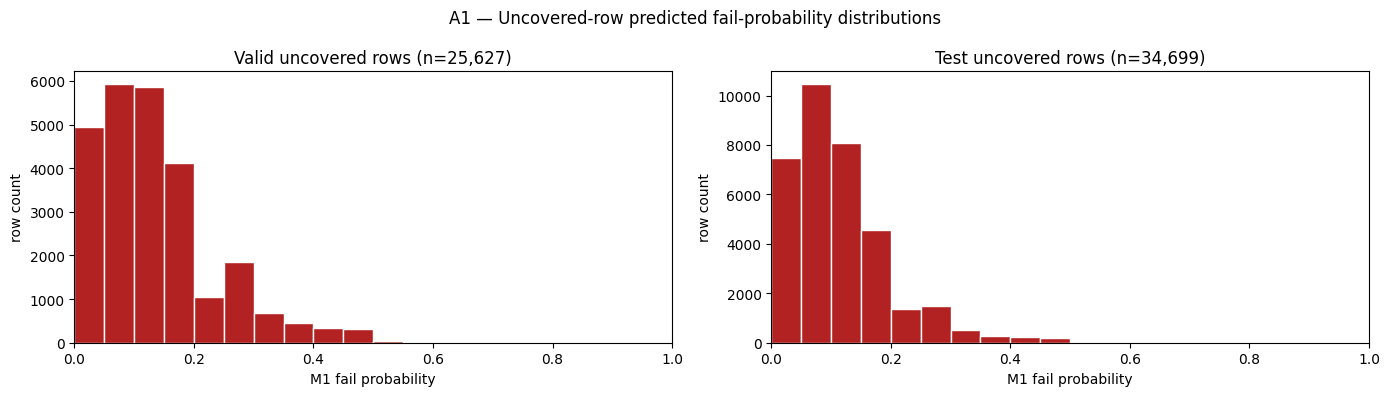

In [6]:
combined = pd.concat([
    df_valid.assign(split='valid'),
    df_test.assign(split='test'),
], ignore_index=True)
coverage_by_year = (
    combined
    .groupby('part_year', dropna=False)
    .agg(row_count=('covered', 'size'), covered_rows=('covered', 'sum'))
    .reset_index()
    .sort_values('part_year')
)
coverage_by_year['coverage_rate_pct'] = coverage_by_year['covered_rows'] / coverage_by_year['row_count'] * 100

print('\n' + '=' * 90)
print('A1 COVERAGE RATE BY YEAR — VALID + TEST')
print('=' * 90)
print(coverage_by_year.to_string(index=False, formatters={'coverage_rate_pct': '{:.2f}%'.format}))

uncovered_probability_reports = {}
histogram_payload = {}
for split_name, frame in [('valid', df_valid), ('test', df_test)]:
    uncovered_prob = frame.loc[~frame['covered'], 'fail_probability']
    desc = uncovered_prob.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    counts, edges = np.histogram(uncovered_prob, bins=20, range=(0.0, 1.0))
    uncovered_probability_reports[split_name] = {str(key): _json_scalar(value) for key, value in desc.items()}
    histogram_payload[split_name] = {
        'bin_edges': [float(value) for value in edges],
        'counts': [int(value) for value in counts],
    }
    print('\n' + '-' * 90)
    print(f'A1 UNCOVERED {split_name.upper()} — FAIL-PROBABILITY DISTRIBUTION')
    print('-' * 90)
    print(desc.to_string())
    print('\nHistogram (20 equal-width bins from 0 to 1):')
    for left, right, count in zip(edges[:-1], edges[1:], counts):
        right_bracket = ']' if np.isclose(right, 1.0) else ')'
        print(f'  [{left:0.2f}, {right:0.2f}{right_bracket}: {count:>8,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for axis, (split_name, frame) in zip(axes, [('valid', df_valid), ('test', df_test)]):
    values = frame.loc[~frame['covered'], 'fail_probability']
    axis.hist(values, bins=20, range=(0, 1), color='#b22222', edgecolor='white')
    axis.set_title(f'{split_name.title()} uncovered rows (n={len(values):,})')
    axis.set_xlabel('M1 fail probability')
    axis.set_ylabel('row count')
    axis.set_xlim(0, 1)
fig.suptitle('A1 — Uncovered-row predicted fail-probability distributions')
fig.tight_layout()
plt.show()

In [7]:
# Explicit sanity display for the diploma_type_id=51 cohort called out in the
# 2021/temporal bucketing work. The result is based on cid_stats membership only.
diploma_51 = df_test.loc[pd.to_numeric(df_test['diploma_type_id'], errors='coerce').eq(51)].copy()
sanity_columns = ['course_id', 'part_year', 'covered']
if 'difficulty_fallback_level' in diploma_51.columns:
    sanity_columns.append('difficulty_fallback_level')
diploma_51_courses = (
    diploma_51
    .groupby(sanity_columns, dropna=False)
    .size()
    .reset_index(name='row_count')
    .sort_values(['row_count', 'course_id'], ascending=[False, True])
)
diploma_51_courses['membership_result'] = np.where(
    diploma_51_courses['covered'],
    'COVERED — course_id is present in train cid_stats',
    'UNCOVERED — course_id is absent from train cid_stats',
)

print('\n' + '=' * 90)
print('A1 SANITY CHECK — RECENT diploma_type_id=51 TEST COURSES')
print('=' * 90)
if diploma_51_courses.empty:
    print('No diploma_type_id=51 rows were found in df_test; no sample is available.')
else:
    print('Each row below is confirmed directly against the train-derived cid_stats course_id set.')
    print('A truly new course must show UNCOVERED; a previously observed course must show COVERED.')
    print(diploma_51_courses.head(10).to_string(index=False))

audit_payload = {
    'diagnostic': 'A1 course-stat coverage audit',
    'run_directory': str(LATEST_RUN_DIR),
    'm1_model_path': str(M1_MODEL_PATH),
    'split_paths': {'train': str(TRAIN_PATH), 'valid': str(VALID_PATH), 'test': str(TEST_PATH)},
    'coverage_definition': (
        'covered = df["course_id"].isin(train_covered_course_ids), where '
        'train_covered_course_ids is cid_stats["course_id"] from the train-only Level-2 course-stat table'
    ),
    'train_cid_stats_course_id_count': int(len(train_covered_course_ids)),
    'subset_metrics': [{key: _json_scalar(value) for key, value in row.items()} for row in subset_rows],
    'coverage_by_year': [
        {key: _json_scalar(value) for key, value in row.items()}
        for row in coverage_by_year.to_dict(orient='records')
    ],
    'uncovered_fail_probability_describe': uncovered_probability_reports,
    'uncovered_fail_probability_histogram': histogram_payload,
    'diploma_type_51_course_sanity_sample': [
        {key: _json_scalar(value) for key, value in row.items()}
        for row in diploma_51_courses.head(10).to_dict(orient='records')
    ],
}

with A1_OUTPUT_PATH.open('w', encoding='utf-8') as handle:
    json.dump(audit_payload, handle, indent=2, ensure_ascii=False, allow_nan=False)

print(f'\nSaved A1 diagnostic JSON: {A1_OUTPUT_PATH}')
print('metrics.json was not read, modified, or overwritten.')


A1 SANITY CHECK — RECENT diploma_type_id=51 TEST COURSES
Each row below is confirmed directly against the train-derived cid_stats course_id set.
A truly new course must show UNCOVERED; a previously observed course must show COVERED.
course_id  part_year  covered  difficulty_fallback_level  row_count                                    membership_result
 1423.111       2025    False                          5        302 UNCOVERED — course_id is absent from train cid_stats
 1421.111       2025    False                          4        288 UNCOVERED — course_id is absent from train cid_stats
 1422.111       2025    False                          4        281 UNCOVERED — course_id is absent from train cid_stats
 1423.111       2025    False                          4        265 UNCOVERED — course_id is absent from train cid_stats
 1440.111       2025    False                          5        244 UNCOVERED — course_id is absent from train cid_stats
 1441.111       2025    False           